In [1]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.circuit import Parameter

import numpy as np
from scipy.optimize import minimize

import matplotlib.pyplot as plt

2-Qubit Variational Circuit:
     ┌────────┐     ┌───────┐
q_0: ┤ Ry(θ₁) ├──■──┤ Ry(φ) ├
     ├────────┤┌─┴─┐└───────┘
q_1: ┤ Ry(θ₂) ├┤ X ├─────────
     └────────┘└───┘         


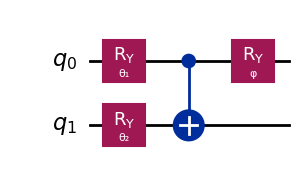

In [2]:
#Demonstrating entanglement and more complex parameterized circuits.

# Create parameters for our 2-qubit circuit
theta1=Parameter('θ₁')
theta2=Parameter('θ₂')
phi=Parameter('φ')

# Create a 2-qubit variational circuit
qc_2qubit=QuantumCircuit(2)

# Apply parameterized rotations to each qubit
qc_2qubit.ry(theta1,0)                   # Rotate first qubit
qc_2qubit.ry(theta2, 1)                  # Rotate second qubit

# Add an entangling gate (CNOT)
qc_2qubit.cx(0,1)

# Add another parameterized rotation
qc_2qubit.ry(phi,0)

print('2-Qubit Variational Circuit:')
print(qc_2qubit)
qc_2qubit.draw('mpl')


# θ₁, θ₂: Rotations on individual qubits
# CNOT: Creates entanglement between qubits
# φ: Additional rotation after entanglement
# This circuit can create entangled states and has more expressive power than the 1-qubit case.

In [3]:
#Cost Function for 2-Qubit Circuit
#Let's define a target state for our 2-qubit circuit. 
# We'll try to prepare a Bell state: |Φ⁺⟩ = (|00⟩ + |11⟩)/√2


#Define the target bell state 
target_state=Statevector([1/np.sqrt(2),0,0,1/np.sqrt(2)])

print(f'Target Bell state |Φ⁺⟩: {target_state}')


#defining the cost function
def cost_function(angles):                                                 #Calculate the cost for the 2-qubit circuit.   angles: array [theta1, theta2, phi]
    theta1_val,theta2_val,phi_val=angles
      # Assign parameters to the circuit
    qc_angles=qc_2qubit.assign_parameters({theta1:theta1_val,theta2:theta2_val,phi:phi_val})

    # Get the statevector directly from the circuit
    state=Statevector.from_instruction(qc_angles)

    overlap=state.inner(target_state)
     # Calculate fidelity
    fidelity=abs(overlap)**2
    cost=1-fidelity
    return cost    #Return cost


Target Bell state |Φ⁺⟩: Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.70710678+0.j],
            dims=(2, 2))


In [4]:
# Test with random parameters
test_angles=np.random.uniform(0,2*np.pi,3)
test_cost= cost_function(test_angles)
print(f"Test parameters: θ₁={test_angles[0]:.3f}, θ₂={test_angles[1]:.3f}, φ={test_angles[2]:.3f}")
print(f"Cost: {test_cost:.4f}, Fidelity: {1 - test_cost:.4f}")

Test parameters: θ₁=1.492, θ₂=5.846, φ=3.656
Cost: 0.9343, Fidelity: 0.0657


In [5]:
#Optimizing the 2-Qubit Circuit

# Initial guess for all three parameters
initial_angles=np.random.uniform(0,2*np.pi,3)

# Optimize
result=minimize(cost_function,initial_angles,method='BFGS')

theta1_optimum=result.x[0]
theta2_optimum=result.x[1]
phi_optimum=result.x[2]
optimal_cost=result.fun

print(result.message)
print('\n')
print(f"Optimal angles , θ₁={theta1_optimum:.4f} rad,θ₂={theta2_optimum:.4f} rad, φ={phi_optimum:.4f} rad")
print(f"Optimal angles , θ₁={np.degrees(theta1_optimum):.3f} degree ,θ₂={np.degrees(theta2_optimum):.3f} degree, φ={np.degrees(phi_optimum):.3f} degree")
print(f"Final cost={optimal_cost:.3f}")
print(f"Fidelity={1-optimal_cost :.3f}")

Optimization terminated successfully.


Optimal angles , θ₁=1.5708 rad,θ₂=-0.0000 rad, φ=6.2832 rad
Optimal angles , θ₁=90.000 degree ,θ₂=-0.000 degree, φ=360.000 degree
Final cost=0.000
Fidelity=1.000


In [6]:
# Verify the final state

qc_final=qc_2qubit.assign_parameters({theta1:theta1_optimum,theta2:theta2_optimum,phi:phi_optimum})
state_final=Statevector.from_instruction(qc_final)

print("Final state from optimized 2-qubit circuit:")
print(state_final)

print("\nTarget Bell state |Φ⁺⟩:")
print(target_state) 
print(f"\nFidelity: {abs(state_final.inner(target_state))**2:.4f}")                             #Optimal θ₁ = 1.5708 radians (90.00°)
                                                                                                #Optimal θ₂ = 6.2832 radians (360.00°)
                                                                                                #Optimal φ = 6.2832 radians (360.00°)
                                                                                                #Final cost: 0.000000
                                                                                                #Final fidelity: 1.000000


Final state from optimized 2-qubit circuit:
Statevector([-7.07106846e-01+0.j,  8.77084740e-07+0.j, -3.08028852e-08+0.j,
             -7.07106717e-01+0.j],
            dims=(2, 2))

Target Bell state |Φ⁺⟩:
Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.70710678+0.j],
            dims=(2, 2))

Fidelity: 1.0000


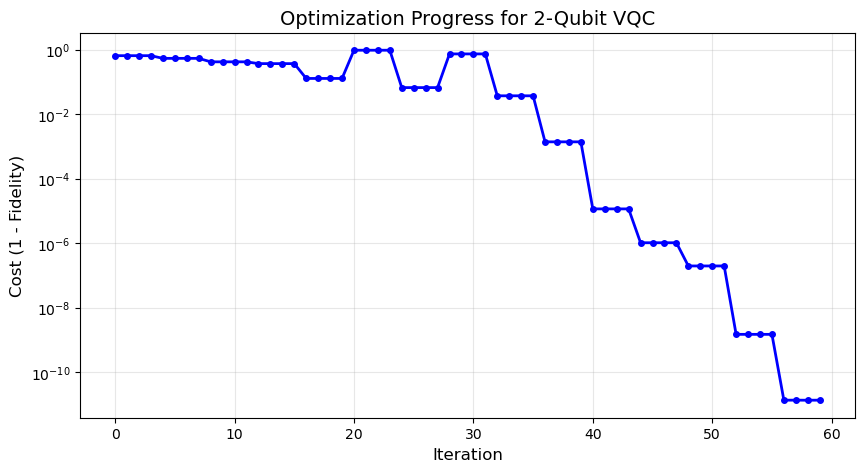

Converged after 60 iterations
Final cost: 0.000000


In [7]:
#Visualizing the 2-Qubit Circuit Evolution
# Track optimization progress

cost_history=[]

def cost_with_history(angles):
    cost=cost_function(angles)
    cost_history.append(cost)
    return cost

# Reset history and optimize again
cost_history = []
initial_params = np.random.uniform(0, 2*np.pi, 3)
result = minimize(cost_with_history, initial_params, method='BFGS', options={'maxiter': 50})


# Plot optimization progress
plt.figure(figsize=(10, 5))
plt.plot(cost_history, 'b-', linewidth=2, marker='o', markersize=4)                #uses the list index as the x-axis
                                                                                   #uses the list values as the y-axis
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Cost (1 - Fidelity)', fontsize=12)
plt.title('Optimization Progress for 2-Qubit VQC', fontsize=14)
plt.grid(True, alpha=0.3)
plt.yscale('log')  # Use log scale to see convergence better
plt.show()

print(f"Converged after {len(cost_history)} iterations")
print(f"Final cost: {cost_history[-1]:.6f}")